In [1]:
import utils
import numpy as np
import pandas as pd
import os
import importlib
import glob
import re
import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('display.max_rows', None)

# Exclusion criteria
- Check only the last two blocks
- cutoff for congruent = 60%
- cutoff for incongruent = 100% - congruent + 10%

In [2]:
# Preparation
unique_subject_ids = [13]#[802,803,804,805,806,807,808,809,810,811,813,814,815]
unique_sessions = [2]
use_second_block = True
plot_range = [0, 6]
raw_output_path = '/Volumes/project/3025011.02/raw/'

recent_results = utils.analysis_functions.list_files_with_date_and_subject_id(raw_output_path, unique_subject_ids, unique_sessions)

In [3]:
combined_results_dataframe = utils.analysis_functions.combine_result_files(recent_results)
unique_subject_ids = combined_results_dataframe['subject_id'].unique()
unique_sessions = combined_results_dataframe['session'].unique()
print(combined_results_dataframe)

     trial  emotional_cue_time response objectively_correct  \
0        0        1.743600e+09      NaN                Late   
1        1        1.743600e+09       up                Even   
2        2        1.743600e+09       up                Even   
3        3        1.743600e+09     down                Even   
4        4        1.743600e+09       up                Even   
5        5        1.743600e+09       up                Even   
6        6        1.743600e+09     down                Even   
7        7        1.743600e+09     down               False   
8        8        1.743600e+09       up                Even   
9        9        1.743600e+09       up               False   
10      10        1.743600e+09     down               False   
11      11        1.743600e+09       up               False   
12      12        1.743600e+09     down               False   
13      13        1.743600e+09      NaN                Late   
14      14        1.743600e+09       up                

# Add congruency, volatility etc

In [4]:
combined_results_dataframe['congruency'] = combined_results_dataframe.apply(utils.analysis_functions.check_congruency, axis=1)
print(combined_results_dataframe[['stimuli_type','probability_condition','congruency']])

     stimuli_type  probability_condition   congruency
0               2                     50    undefined
1               2                     50    undefined
2               1                     50    undefined
3               2                     50    undefined
4               1                     50    undefined
5               1                     50    undefined
6               2                     50    undefined
7               2                     80  incongruent
8               1                     50    undefined
9               1                     20  incongruent
10              2                     80  incongruent
11              1                     20  incongruent
12              2                     80  incongruent
13              2                     80  incongruent
14              2                     80  incongruent
15              1                     20  incongruent
16              1                     20  incongruent
17              1           

In [5]:
combined_results_dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
combined_results_dataframe = utils.analysis_functions.check_volatility(combined_results_dataframe)
dataframe_volatility_check = combined_results_dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])
print(dataframe_volatility_check[['trial','stimuli_type','probability_condition','volatility']])

     trial  stimuli_type  probability_condition volatility
1        9             1                     20   volatile
3       11             1                     20   volatile
7       15             1                     20   volatile
8       16             1                     20   volatile
9       17             1                     20   volatile
11      19             1                     20   volatile
12      20             1                     20   volatile
14      22             1                     20   volatile
16      24             1                     20   volatile
18      26             1                     20   volatile
19      27             1                     80   volatile
24      32             1                     80   volatile
26      34             1                     80   volatile
27      35             1                     80   volatile
29      37             1                     80   volatile
30      38             1                     80   volati

In [6]:
combined_results_dataframe['valence'] = combined_results_dataframe.apply(utils.analysis_functions.check_valence, axis=1)
print(combined_results_dataframe[['stimuli_type','valence']])

     stimuli_type valence
0               2   happy
1               1   angry
2               2   happy
3               1   angry
4               2   happy
5               2   happy
6               2   happy
7               1   angry
8               1   angry
9               1   angry
10              2   happy
11              1   angry
12              1   angry
13              2   happy
14              1   angry
15              2   happy
16              1   angry
17              2   happy
18              1   angry
19              1   angry
20              2   happy
21              2   happy
22              2   happy
23              2   happy
24              1   angry
25              2   happy
26              1   angry
27              1   angry
28              2   happy
29              1   angry
30              1   angry
31              1   angry
32              2   happy
33              2   happy
34              2   happy
35              2   happy
36              1   angry
37          

In [7]:
# Turns the objective values into boolean ones
mapping = {'True': 1, 'False': 0, 'Even': 0, 'Late': 0}

combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct'].replace(mapping)
combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct_boolean'].astype('int')
print(combined_results_dataframe)

     trial  emotional_cue_time response objectively_correct  \
0        7        1.743600e+09     down               False   
1        9        1.743600e+09       up               False   
2       10        1.743600e+09     down               False   
3       11        1.743600e+09       up               False   
4       12        1.743600e+09     down               False   
5       13        1.743600e+09      NaN                Late   
6       14        1.743600e+09       up                True   
7       15        1.743600e+09     down                True   
8       16        1.743600e+09       up               False   
9       17        1.743600e+09     down                True   
10      18        1.743600e+09       up                True   
11      19        1.743600e+09     down                True   
12      20        1.743600e+09       up               False   
13      21        1.743600e+09     down               False   
14      22        1.743600e+09     down                

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_6514/1487422352.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct'].replace(mapping)


# Remove everything but the last two blocks

In [8]:
# Create a helper column that increments whenever the value changes.
# This assigns a unique group number to each contiguous block.
last_block_stimulus_1 = combined_results_dataframe[combined_results_dataframe['stimuli_type'] == 1]
last_block_stimulus_2 = combined_results_dataframe[combined_results_dataframe['stimuli_type'] == 2]
last_block_stimulus_1['group'] = (last_block_stimulus_1['volatility'] != last_block_stimulus_1['volatility'].shift()).cumsum()
last_block_stimulus_2['group'] = (last_block_stimulus_2['volatility'] != last_block_stimulus_2['volatility'].shift()).cumsum()

# Get the top two values from the "group" column
unique_groups = last_block_stimulus_1['group'].unique()
if use_second_block:
    top_two = sorted(unique_groups, reverse=True)[2:4]
else:
    top_two = sorted(unique_groups, reverse=True)[:2]
print(top_two)
# Filter the DataFrame to include only rows with these top two values
last_block_stimulus_1 = last_block_stimulus_1[last_block_stimulus_1['group'].isin(top_two)]
# Get the top two values from the "group" column
unique_groups = last_block_stimulus_2['group'].unique()
if use_second_block:
    top_two = sorted(unique_groups, reverse=True)[2:4]
else:
    top_two = sorted(unique_groups, reverse=True)[:2]
print(top_two)
# Filter the DataFrame to include only rows with these top two values
last_block_stimulus_2 = last_block_stimulus_2[last_block_stimulus_2['group'].isin(top_two)]

frames = [last_block_stimulus_1, last_block_stimulus_2]

last_block_stimulus = pd.concat(frames)

last_blocks_results = last_block_stimulus.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

# Filter to keep only rows that belong to these last blocks
print(last_blocks_results[['trial','stimuli_type','volatility','group']])
last_blocks_results.drop(columns='group', inplace=True)

#last_blocks_results = combined_results_dataframe

[4, 3]
[4, 3]
     trial  stimuli_type volatility  group
241    249             1   volatile      3
242    250             1   volatile      3
245    253             1   volatile      3
247    255             1   volatile      3
249    257             1   volatile      3
252    260             1   volatile      3
253    261             1   volatile      3
255    263             1   volatile      3
257    265             1   volatile      3
259    267             1   volatile      3
260    268             1   volatile      3
262    270             1   volatile      3
264    272             1   volatile      3
266    274             1   volatile      3
268    276             1   volatile      3
269    277             1   volatile      3
272    280             1   volatile      3
275    283             1   volatile      3
277    285             1   volatile      3
279    287             1   volatile      3
281    289             1   volatile      3
282    290             1   volatile     

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_6514/2731548471.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_block_stimulus_1['group'] = (last_block_stimulus_1['volatility'] != last_block_stimulus_1['volatility'].shift()).cumsum()
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_6514/2731548471.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_block_stimulus_2['group'] = (last_block_stimulus_2['volatility'] != last_block_stimulus_2['volatility'].shift()).cumsum()


In [9]:
# Optionally, remove the helper column
print(last_blocks_results[['stimuli_type','congruency','volatility']])

     stimuli_type   congruency volatility
241             1    congruent   volatile
242             1    congruent   volatile
245             1    congruent   volatile
247             1    congruent   volatile
249             1    congruent   volatile
252             1    congruent   volatile
253             1  incongruent   volatile
255             1  incongruent   volatile
257             1  incongruent   volatile
259             1  incongruent   volatile
260             1  incongruent   volatile
262             1  incongruent   volatile
264             1  incongruent   volatile
266             1  incongruent   volatile
268             1    congruent   volatile
269             1    congruent   volatile
272             1    congruent   volatile
275             1    congruent   volatile
277             1    congruent   volatile
279             1    congruent   volatile
281             1    congruent   volatile
282             1    congruent   volatile
285             1    congruent   v

In [10]:
# Create new plots with different intervals that also contain the 50% trials
unique_stimuli_types = last_blocks_results['stimuli_type'].unique()
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6}
group_name = 'congruency'
session_name = 'session'
unique_group_types = last_blocks_results[group_name].unique()


all_switches_dataframe = utils.analysis_functions.find_switches_in_dataframe(last_blocks_results,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping, session_name)
print(all_switches_dataframe)

    subject_id  trial  stimuli_type  probability_condition switch  \
241    sub-013    249             1                     80  False   
242    sub-013    250             1                     80  False   
245    sub-013    253             1                     80  False   
247    sub-013    255             1                     80  False   
249    sub-013    257             1                     80  False   
252    sub-013    260             1                     80  False   
253    sub-013    261             1                     20   True   
255    sub-013    263             1                     20  False   
257    sub-013    265             1                     20  False   
259    sub-013    267             1                     20  False   
260    sub-013    268             1                     20  False   
262    sub-013    270             1                     20  False   
264    sub-013    272             1                     20  False   
266    sub-013    274             

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:568: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_fun

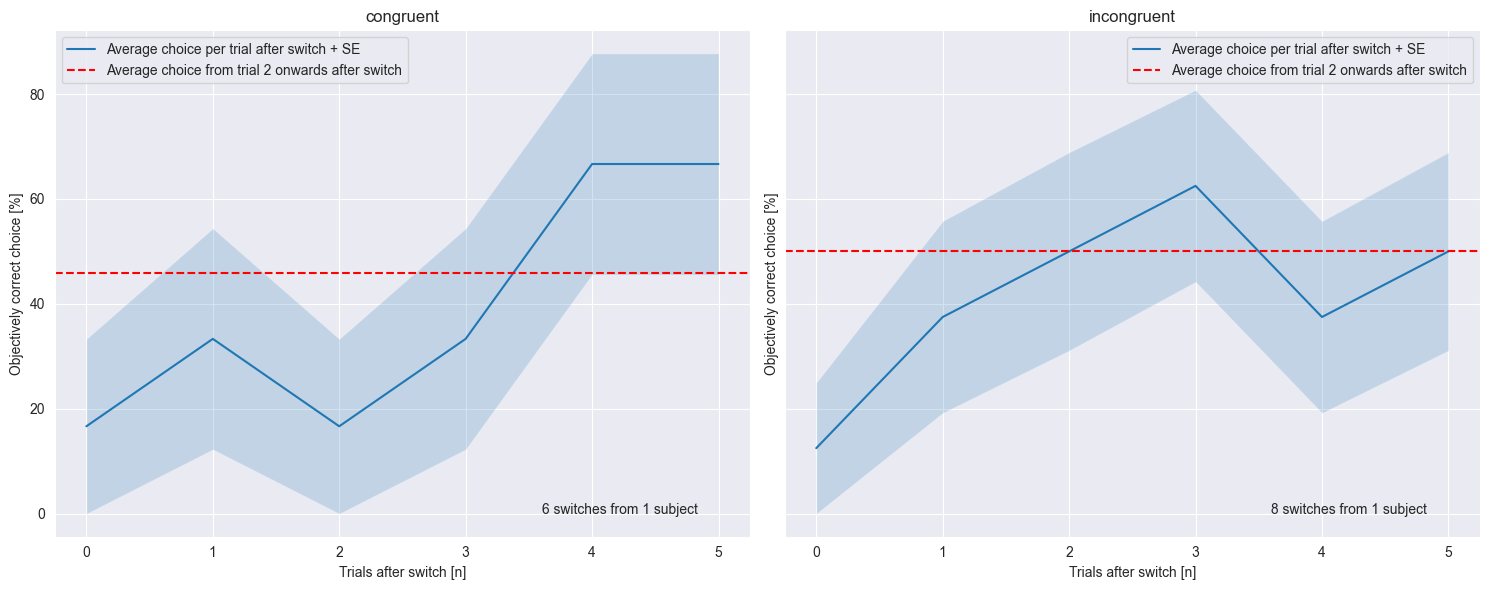

In [11]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe.set_index('congruency')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])
df = df.drop(columns=['session'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('congruency').mean()
means = means*100
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('congruency').sem()
stds = stds * 100

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

#fig.suptitle('Objective performance grouped for congruency', fontsize=24, y=0.982)

congruency_list = all_switches_dataframe['congruency'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    if congruency_type != 'undefined':
        # Timepoints are the column names converted to integers for x-axis values
        timepoints = list(range(plot_range[0], plot_range[1]))
        mean_values = means.loc[congruency_type]
        std_values = stds.loc[congruency_type]

        axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
        axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
        axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
        #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
        axs[i].set_title(congruency_type)
        axs[i].set_xlabel('Trials after switch [n]')
        axs[i].set_ylabel('Objectively correct choice [%]')
        axs[i].text(3.6, 0, f'{group_counts[congruency_type]} switches from {subject_counts} subject', fontsize=10)
        axs[i].legend()
        axs[i].grid(True)

plt.tight_layout()
plt.show()

Mean score for the congruent condition 40.00% is below the 60% threshold.
Exclude the participant.



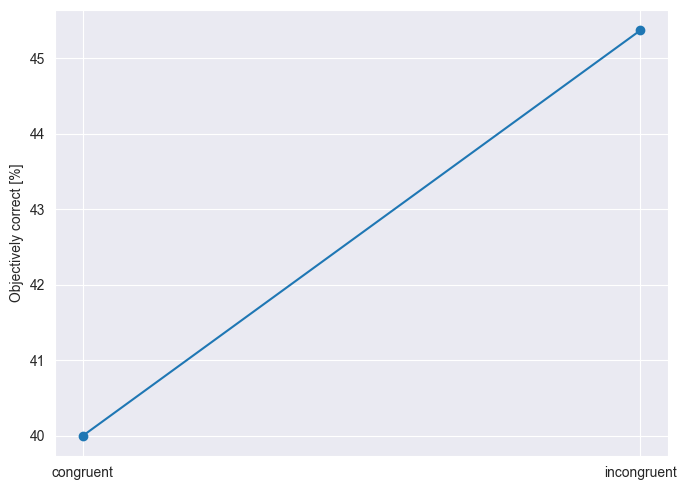

In [12]:
# Comparing overall congruency performance difference
dataframe_1 = last_blocks_results[last_blocks_results['congruency'] == 'congruent']
dataframe_1 = dataframe_1.groupby(['subject_id', 'session'])['objectively_correct_boolean'].mean().reset_index()
list_1 = dataframe_1['objectively_correct_boolean'].dropna().tolist()
congruent_score = list_1[0] * 100
dataframe_2 = last_blocks_results[last_blocks_results['congruency'] == 'incongruent']
dataframe_2 = dataframe_2.groupby(['subject_id', 'session'])['objectively_correct_boolean'].mean().reset_index()
list_2 = dataframe_2['objectively_correct_boolean'].dropna().tolist()
incongruent_score = list_2[0] * 100

# Plot data
fig, ax = plt.subplots(figsize=(7, 5))
subject_data = pd.DataFrame.from_dict({'x': [1, 2], 'data': [congruent_score, incongruent_score]})
plt.plot(subject_data['x'], subject_data['data'], marker='o')

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['congruent', 'incongruent'])  # Set text labels.
plt.ylabel('Objectively correct [%]')
plot_name = 'all_trials_objective_performance_congruency'

# Determine whether participant meets cutoff criteria
cutoff_opposite = 100 - congruent_score + 10
if congruent_score < 60:
    print(f'Mean score for the congruent condition {congruent_score:.2f}% is below the 60% threshold.\n'
          'Exclude the participant.\n')
    participant_excluded = True
elif incongruent_score < 40:
    print(f'Mean score for the incongruent condition {incongruent_score:.2f}% is below the 40% threshold.\n'
          'Exclude the participant.\n')
    participant_excluded = True
elif incongruent_score < cutoff_opposite:
    print(f'Mean score for the incongruent condition {incongruent_score:.2f}% is below the threshold 100 - congruent score + 10 ({cutoff_opposite:.2f}%).\n'
          'Exclude the participant.\n')
    participant_excluded = True
else:
    print(f'Mean score for the congruent condition {congruent_score}% and incongruent condition {incongruent_score}% fall within the cutoffs.\n'
    'Include the participant.\n')
    participant_excluded = False

# Show plot
plt.tight_layout()
plt.show()

# Reaction time check

29 out of 660 trials are non-response trials
So, 4.39% of the trials are non-response trials
Include the participant.

Participant locked the joystick in 253 out of 660 trials
That's 38.33% of the trials
This means that the participant locked the joystick in more than 10% of the trials.
Exclude the participant.



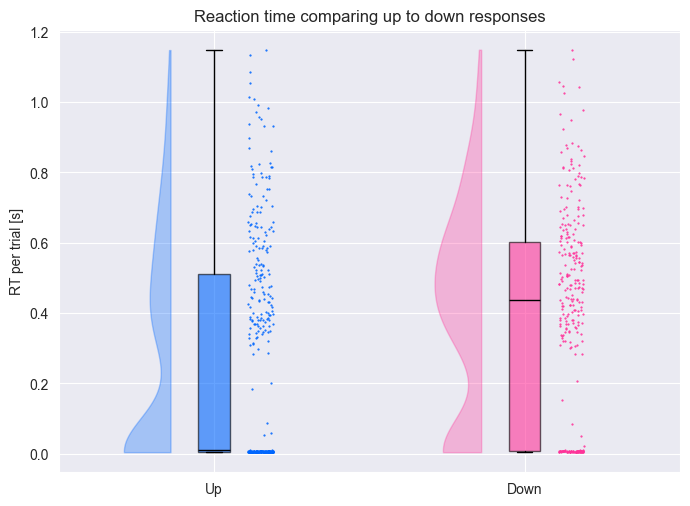

In [13]:
# Print percentage of non-response trials
non_response_trials = combined_results_dataframe[combined_results_dataframe['response'].isna()]
percentage_responses = len(non_response_trials)/len(combined_results_dataframe)*100

if percentage_responses > 10:
    print(f'{len(non_response_trials)} out of {len(combined_results_dataframe)} trials are non-response trials\n'
      f'So, {percentage_responses:.2f}% of the trials are non-response trials\n'
      'This means that the participant responded in less than 90% of the trials.\n'
          'Exclude the participant.\n')
    participant_excluded = True
else:
    print(f'{len(non_response_trials)} out of {len(combined_results_dataframe)} trials are non-response trials\n'
      f'So, {percentage_responses:.2f}% of the trials are non-response trials\n'
          'Include the participant.\n')
    participant_excluded = False

joystick_locked_trials = combined_results_dataframe[combined_results_dataframe['RT_s'] < 0.05]
percentage_joystick_locked = len(joystick_locked_trials)/len(combined_results_dataframe)*100

if percentage_joystick_locked > 10:
    print(f'Participant locked the joystick in {len(joystick_locked_trials)} out of {len(combined_results_dataframe)} trials\n'
      f"That's {percentage_joystick_locked:.2f}% of the trials\n"
      'This means that the participant locked the joystick in more than 10% of the trials.\n'
          'Exclude the participant.\n')
    participant_excluded = True
else:
    print(f'Participant locked the joystick in {len(joystick_locked_trials)} out of {len(combined_results_dataframe)} trials\n'
      f"That's {percentage_joystick_locked:.2f}% of the trials\n"
          'Include the participant.\n')
    participant_excluded = False

# Plot reaction time
happy_dataframe = combined_results_dataframe[combined_results_dataframe['response'] == 'up']
happy_list = happy_dataframe['RT_s'].dropna().tolist()
angry_dataframe = combined_results_dataframe[combined_results_dataframe['response'] == 'down']
angry_list = angry_dataframe['RT_s'].dropna().tolist()
valence_list = [happy_list, angry_list]

# Create empty plot
fig, ax = plt.subplots(figsize=(7, 5))

# Create a list of colors
plot_colors = ['#0066ff', '#ff3399']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['Up', 'Down'])  # Set text labels.
plt.ylabel('RT per trial [s]')
plot_name = 'Reaction time comparing up to down responses'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.show()

In [14]:
if participant_excluded:
    raise Exception('Participant excluded on behavioural criteria')

Exception: Participant excluded on behavioural criteria

# Adjust simulations
- Check MI Skin and Brain to see if it's below 1.9
- Check CEM43 skin and brain to see if it's below 0.25

In [72]:
simulation_directory = f'/Volumes/project/3025011.02/TUS_simulations/planning/'

stimulation_output_full_filenames_1 = os.path.join(simulation_directory, '**', '*layered_output_table_target_1*.csv')
stimulation_output_full_filenames_2 = os.path.join(simulation_directory, '**', '*layered_output_table_target_2*.csv')
stimulation_output_full_filenames_3 = os.path.join(simulation_directory, '**', '*layered_output_table_target_3*.csv')

stimulation_output_full_filenames = glob.glob(stimulation_output_full_filenames_1, recursive=True) + glob.glob(stimulation_output_full_filenames_2, recursive=True)

stimulation_output_full_filenames = [s for s in stimulation_output_full_filenames if unique_subject_ids[0] in s]
if not stimulation_output_full_filenames:
    raise Exception('No files found')
print(stimulation_output_full_filenames)

['/Volumes/project/3025011.02/TUS_simulations/planning/target_2_5/sub-011/sub-011_layered_output_table_target_2_5_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_2_5/sub-011/sub-011_layered_output_table_target_2_5_dc20_strength_3.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_2_6/sub-011/sub-011_layered_output_table_target_2_6_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_2_6/sub-011/sub-011_layered_output_table_target_2_6_dc20_strength_3.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_2_1/sub-011/sub-011_layered_output_table_target_2_1_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_2_1/sub-011/sub-011_layered_output_table_target_2_1_dc20_strength_3.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_2_2/sub-011/sub-011_layered_output_table_target_2_2_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/

In [73]:
# List to hold individual dataframes
list_of_dataframes = []

# Process each CSV file
for stimulation_output_full_filename in stimulation_output_full_filenames:
    # Extract the filename (without the path)
    stimulation_output_filename = os.path.basename(stimulation_output_full_filename)
    # Remove the '.csv' extension
    stimulation_output_filename_without_extension = os.path.splitext(stimulation_output_filename)[0]

    # Split the filename by underscores
    stimulation_output_filename_parts = stimulation_output_filename_without_extension.split('_')

    # Extract the desired parts from the filename:
    subject_id = stimulation_output_filename_parts[0]                     # e.g. 'sub-010'
    target = '_'.join(stimulation_output_filename_parts[4:7])               # e.g. 'target_2_2'
    duty_cycle = stimulation_output_filename_parts[7]                       # e.g. 'dc1'
    intensity = '_'.join(stimulation_output_filename_parts[8:10])           # e.g. 'strength_1'

    # Read the CSV file (assuming it contains one row)
    try:
        df = pd.read_csv(stimulation_output_full_filename)
    except Exception as e:
        print(f"Error reading {stimulation_output_full_filename}: {e}")
        continue  # Skip this file if there's an error

    # Add the extracted metadata as new columns
    df['target'] = target
    df['intensity'] = intensity
    df['duty_cycle'] = duty_cycle

    # Append the dataframe to our list
    list_of_dataframes.append(df)

# Combine all dataframes into one
if list_of_dataframes:
    stimulation_output = pd.concat(list_of_dataframes, ignore_index=True)
    print(stimulation_output)
else:
    raise Exception("No CSV files were found or processed.")

    subject_id  max_Isppa  max_Isppa_after_exit_plane  real_focal_distance  \
0           11  12.417530                   12.417530            40.015622   
1           11  28.623290                   23.569230            40.015622   
2           11   9.091639                    9.091639            42.002976   
3           11  33.350180                   33.350180            42.002976   
4           11  12.886250                   12.886250            46.000000   
5           11  31.062370                   31.062370            46.000000   
6           11  13.046130                   13.046130            42.505882   
7           11  39.780880                   39.780880            43.005814   
8           11  13.716390                   13.716390            48.002604   
9           11  29.438280                   29.438280            47.500000   
10          11   9.745646                    9.745646            35.507042   
11          11  27.635610                   27.635610           

In [74]:
# Reorder columns
column_indices = list(range(stimulation_output.shape[1]))
reordered_column_indices = [column_indices[0]] + column_indices[-3:] + column_indices[1:-3]
stimulation_output = stimulation_output.iloc[:, reordered_column_indices]
stimulation_output.sort_values(by=['subject_id', 'target', 'intensity', 'duty_cycle'], inplace=True)
stimulation_output.reset_index(drop=True, inplace=True)
stimulation_output['CEM43_brain_skin'] = stimulation_output[['CEM43_brain', 'CEM43_skin']].max(axis=1)
# Replace values to improve readability
stimulation_output['duty_cycle'] = stimulation_output['duty_cycle'].map({'dc10': '10%', 'dc15': '15%', 'dc20': '20%'})
stimulation_output['intensity'] = stimulation_output['intensity'].map({'strength_1': '35', 'strength_2': '63', 'strength_3': '81', 'strength_4': '110'})
# Now drop some columns
stimulation_output.drop(
    ['real_focal_distance','Ix_brain', 'Iy_brain','Iz_brain',
     'max_pressure_brain','max_pressure_skull','max_pressure_skin',
     'riseT_brain', 'riseT_skull', 'riseT_skin','isppa_at_target',
     'max_Isppa','half_max_ISPPA_volume_brain','avg_isppa_around_target',
     'focus_pos_final_1', 'focus_pos_final_2', 'focus_pos_final_3',
     'trans_pos_final_1', 'trans_pos_final_2', 'trans_pos_final_3'],
    axis=1,
    inplace=True
)

print(stimulation_output)

    subject_id      target intensity duty_cycle  max_Isppa_after_exit_plane  \
0           11  target_2_1        35        20%                   12.886250   
1           11  target_2_1        81        20%                   31.062370   
2           11  target_2_2        35        20%                   13.046130   
3           11  target_2_2        81        20%                   39.780880   
4           11  target_2_3        35        20%                   13.716390   
5           11  target_2_3        81        20%                   29.438280   
6           11  target_2_4        35        20%                    9.745646   
7           11  target_2_4        81        20%                   27.635610   
8           11  target_2_5        35        20%                   12.417530   
9           11  target_2_5        81        20%                   23.569230   
10          11  target_2_6        35        20%                    9.091639   
11          11  target_2_6        81        20%     

In [75]:
# Create mask for rows where either of the limits are exceeded
MI_mask = (
    (stimulation_output['max_MI_skin'] > 1.9) |
    (stimulation_output['max_MI_brain'] > 1.9)
)
CEM43_mask = (
    (stimulation_output['CEM43_skin'] > 0.25) |
    (stimulation_output['CEM43_brain'] > 0.25)
)

# Filter the rows and select the desired columns
simulations_exceeding_MI = stimulation_output[MI_mask]
simulations_exceeding_CEM43 = stimulation_output[CEM43_mask]

# Print the rows where the MI is exceeded
for _, row in simulations_exceeding_MI.iterrows():
    exceeded = {}
    if row['max_MI_skin'] > 1.9:
        exceeded['max_MI_skin'] = row['max_MI_skin']
    if row['max_MI_brain'] > 1.9:
        exceeded['max_MI_brain'] = row['max_MI_brain']

    print(f"{row['target']} with an intensity of {row['intensity']}W/cm2 and a duty_cycle of {row['duty_cycle']}, exceeded the MI limits in the following tissues: {exceeded}")
    participant_excluded = True

target_2_1 with an intensity of 81W/cm2 and a duty_cycle of 20%, exceeded the MI limits in the following tissues: {'max_MI_skin': 1.906329}
target_2_2 with an intensity of 81W/cm2 and a duty_cycle of 20%, exceeded the MI limits in the following tissues: {'max_MI_skin': 2.157336}
target_2_6 with an intensity of 81W/cm2 and a duty_cycle of 20%, exceeded the MI limits in the following tissues: {'max_MI_skin': 1.975284}


In [76]:
# Print the rows where the MI is exceeded
for _, row in simulations_exceeding_CEM43.iterrows():
    exceeded = {}
    if row['CEM43_skin'] > 0.25:
        exceeded['CEM43_skin'] = row['CEM43_skin']
    if row['CEM43_brain'] > 0.25:
        exceeded['CEM43_brain'] = row['CEM43_brain']

    print(f"{row['target']} with an intensity of {row['intensity']}W/cm2 and a duty_cycle of {row['duty_cycle']}, exceeded the CEM43 limits in the following tissues: {exceeded}")
    participant_excluded = True

target_2_5 with an intensity of 81W/cm2 and a duty_cycle of 20%, exceeded the CEM43 limits in the following tissues: {'CEM43_skin': 0.6241928}
target_2_6 with an intensity of 81W/cm2 and a duty_cycle of 20%, exceeded the CEM43 limits in the following tissues: {'CEM43_skin': 0.2813214}


In [77]:
if participant_excluded:
    raise Exception('Participant exceeds stimulation thresholds.\n'
                    'Lower the intensity')

Exception: Participant exceeds stimulation thresholds.
Lower the intensity